In [1]:
import pandas as pd

In [2]:
irisdf = pd.read_csv('/content/Iris.csv')
irisdf

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
lc = irisdf.shape
print(lc[1]) #열이름
print(lc[0]) #행이름


6
150


In [4]:
irisdf.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [5]:
irisdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
import numpy as np
irisdf.isna()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
145,False,False,False,False,False,False
146,False,False,False,False,False,False
147,False,False,False,False,False,False
148,False,False,False,False,False,False


In [7]:
irisdf.isna().sum() #속성별 결측치 확인


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [8]:
irisdf.isna().sum().sum()

np.int64(0)

In [9]:
#R곷받침 평균 구하기
avg_sepal_iength = irisdf['SepalLengthCm'].mean()

In [10]:
#꽆잎 너비 최대치
max_PWCm = irisdf['PetalWidthCm'].max()
print(max_PWCm)

2.5


In [11]:
irisdf.value_count() # 빈도 수 구하기

AttributeError: 'DataFrame' object has no attribute 'value_count'

In [ ]:
petal_length_filtered = irisdf[irisdf['PetalLengthCm'] > 2.0]
num_rows = len(petal_length_filtered)
print(f"꽃잎 길이가 2.0보다 큰 데이터의 개수: {num_rows}")

In [ ]:
7-2 . 8, 12, 15 ,16

In [ ]:
irisdfSepalW = irisdf[irisdf['SepalWidthCm'] > 3.5]
num_rowSW = len(irisdfSepalW)
print(num_rowSW)

In [ ]:
rvirisdf = irisdf[irisdf['Species'] =='Iris-versicolor']
rvirisdfPL = rvirisdf['PetalLengthCm'].mean()
print(rvirisdfPL)

In [ ]:
viririsdf = irisdf[irisdf['Species'] =='Iris-virginica']
viririsdfSW = rvirisdf['SepalWidthCm'].max()
print(viririsdfSW)

In [ ]:
#꽃받침 가장 넓은 종
irisdf['SepalLength']

In [ ]:
# 종류별 꽃받침 길이 평균 계산
avg_sepal_length_by_species = irisdf.groupby('Species')['SepalLengthCm'].mean().reset_index()
avg_sepal_length_by_species = avg_sepal_length_by_species.rename(columns={'SepalLengthCm': 'AverageSepalLengthCm'})

In [ ]:
# 종류별 꽃잎 너비 평균 계산
avg_petal_width_by_species = irisdf.groupby('Species')['PetalWidthCm'].mean().reset_index()
avg_petal_width_by_species = avg_petal_width_by_species.rename(columns={'PetalWidthCm': 'AveragePetalWidthCm'})

In [ ]:
# 두 결과를 합쳐서 표로 정리
comparison_table = pd.merge(avg_sepal_length_by_species, avg_petal_width_by_species, on='Species')
display(comparison_table)

위 표에서:
- **가장 꽃받침이 긴 종류**는 `AverageSepalLengthCm` 값이 가장 높은 종입니다.
- **가장 꽃잎이 넓은 종류**는 `AveragePetalWidthCm` 값이 가장 높은 종입니다.

## 문제 15: 새로운 값 계산하기

꽃받침 면적과 꽃잎 면적을 계산하고, 각 면적이 가장 큰 종을 찾아보겠습니다.

In [ ]:
# 꽃받침 면적(SepalArea)과 꽃잎 면적(PetalArea) 계산
irisdf['SepalArea'] = irisdf['SepalLengthCm'] * irisdf['SepalWidthCm']
irisdf['PetalArea'] = irisdf['PetalLengthCm'] * irisdf['PetalWidthCm']

# 계산된 새로운 컬럼 확인
display(irisdf.head())

In [ ]:
# 종류별 평균 꽃받침 면적 계산
avg_sepal_area_by_species = irisdf.groupby('Species')['SepalArea'].mean().reset_index()

# 종류별 평균 꽃잎 면적 계산
avg_petal_area_by_species = irisdf.groupby('Species')['PetalArea'].mean().reset_index()

# 결과 합치기
area_comparison_table = pd.merge(avg_sepal_area_by_species, avg_petal_area_by_species, on='Species')

display(area_comparison_table)

# 가장 큰 꽃받침 면적을 가진 종 찾기
max_sepal_area_species = avg_sepal_area_by_species.loc[avg_sepal_area_by_species['SepalArea'].idxmax()]
print(f"\n꽃받침 면적이 가장 큰 종류: {max_sepal_area_species['Species']} (평균 면적: {max_sepal_area_species['SepalArea']:.2f})")

# 가장 큰 꽃잎 면적을 가진 종 찾기
max_petal_area_species = avg_petal_area_by_species.loc[avg_petal_area_by_species['PetalArea'].idxmax()]
print(f"꽃잎 면적이 가장 큰 종류: {max_petal_area_species['Species']} (평균 면적: {max_petal_area_species['PetalArea']:.2f})")

## 문제 16: 데이터 필터링

꽃받침 너비가 3.0 이상이고 꽃잎 너비가 1.5 이상인 데이터를 찾아보고, 해당 데이터들이 주로 어떤 종류인지 분석하겠습니다.

In [ ]:
# 조건에 맞는 데이터 필터링
filtered_df = irisdf[(irisdf['SepalWidthCm'] >= 3.0) & (irisdf['PetalWidthCm'] >= 1.5)]

print(f"필터링된 데이터의 행 수: {len(filtered_df)}")
display(filtered_df.head())

In [ ]:
# 필터링된 데이터에서 종(Species) 분포 확인
species_distribution = filtered_df['Species'].value_counts()

print("\n필터링된 데이터의 종 분포:")
display(species_distribution)

위의 종 분포 결과를 통해 필터링된 데이터에서 주로 어떤 종류의 붓꽃이 나타나는지 확인할 수 있습니다.

In [3]:
import matplotlib as plt


In [ ]:
comparison_table

In [ ]:
plt.bar(comparison_table ['Species'],comparison_table ['AverageSepalLengthCm'] )

In [5]:
import matplotlib.pyplot as plt


In [10]:
import matplotlib.pyplot as plt
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv
import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [11]:
import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

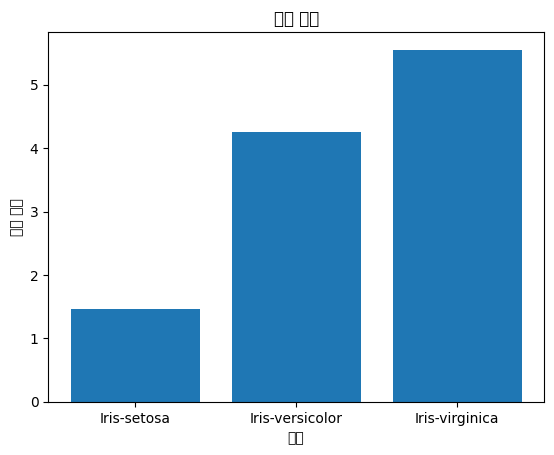

In [12]:
Petal_mean = irisdf.groupby('Species')['PetalLengthCm'].mean()
plt.bar(Petal_mean.index,Petal_mean.values)
plt.xlabel('종류')
plt.ylabel('꽃잎 길이')
plt.title ('꽃잎 길이')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


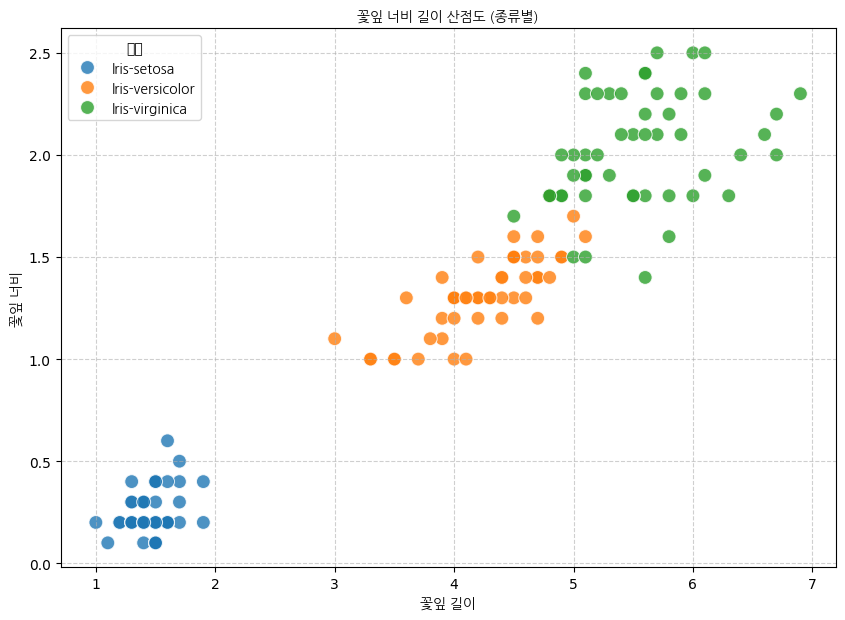

In [14]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (이전 셀에서 font10이 정의되어 있다고 가정)
plt.rc('font', family=font10.get_name())
plt.rc('axes', unicode_minus=False) # 마이너스 부호 깨짐 방지

plt.figure(figsize=(10, 7))

# 각 종(Species)별로 데이터 필터링 및 플로팅
for species_name in irisdf['Species'].unique():
    species_data = irisdf[irisdf['Species'] == species_name]
    plt.scatter(
        species_data['PetalLengthCm'],
        species_data['PetalWidthCm'],
        label=species_name, # 종 이름을 레이블로 사용
        s=100,             # 점의 크기 조절
        alpha=0.8          # 투명도 조절
    )

plt.xlabel('꽃잎 길이', fontproperties=font10)
plt.ylabel('꽃잎 너비', fontproperties=font10)
plt.title('꽃잎 너비 길이 산점도 (종류별)', fontproperties=font10)
plt.legend(title='종류', prop=font10) # 범례 추가 및 한글 폰트 적용
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()